# CE49X Lab 4: Istanbul Earthquake Risk Communication Dashboard
## Visualization for Decision-Makers

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Group Members:**
| Name | Student ID |
|------|------------|
| *(your name)* | *(your ID)* |
| *(partner's name)* | *(partner's ID)* |

## Background

Istanbul sits directly on the **North Anatolian Fault (NAF)**, one of the most active strike-slip faults in the world. The devastating 1999 Izmit earthquake (M7.6) ruptured a segment just 80 km east of the city, and seismologists have long warned that the next major rupture is expected beneath the Sea of Marmara — directly south of Istanbul.

The 2023 Kahramanmaras earthquake sequence (M7.8 + M7.5) demonstrated the catastrophic potential of large earthquakes in Turkey and renewed urgency around earthquake preparedness in Istanbul, a city of over 16 million people.

Effective **risk communication** is critical: decision-makers in municipal government need clear, honest, and actionable visualizations — not just raw data. A misleading colormap or a truncated axis can distort risk perception and lead to poor resource allocation.

> **Key Insight:** Visualization is not decoration — it is a critical tool for communicating risk to non-technical audiences. Every design choice (color, scale, annotation) shapes how decision-makers understand and act on data.

## Scenario

You have been hired as a **visualization consultant** for Istanbul's Disaster Coordination Center (AFAD Istanbul). Your task is to create a set of **publication-quality visualizations** for a risk communication report that will be presented to the **Istanbul Municipal Council** — a non-technical audience of elected officials who must decide how to allocate earthquake preparedness funding across Istanbul's districts.

Your visualizations must be:
- **Accurate** — no misleading scales, truncated axes, or rainbow colormaps
- **Clear** — interpretable by someone without a seismology background
- **Actionable** — each chart should support a specific decision or insight
- **Professional** — publication-ready with proper labels, titles, and annotations

## Data Requirements

You must collect **three categories** of real data. No data files are provided — you are responsible for sourcing, downloading, and documenting your data. For each dataset, record the **source URL**, **date accessed**, **how you obtained it**, and **number of records**.

### 1. Earthquake Catalog (required)

Historical earthquakes for the Marmara region. You need **at least 200 earthquakes** with year, latitude, longitude, depth, and magnitude.

Suggested sources:
- **AFAD Earthquake Department**: [deprem.afad.gov.tr](https://deprem.afad.gov.tr) — Turkey's official earthquake catalog, searchable by region/date/magnitude, downloadable as CSV
- **KOERI (Kandilli Observatory)**: [koeri.boun.edu.tr](http://www.koeri.boun.edu.tr) — Bogazici University's own seismology center
- **USGS Earthquake Catalog**: [earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/) — global catalog, CSV export, filter by lat/lon bounding box (e.g., 40-41.5°N, 27-31°E for the Marmara region)

### 2. Building / Population Data (required)

Istanbul district-level data on buildings and/or population. You need data for **at least 10 Istanbul districts** with population and at least one building-related metric (age, type, or count).

Suggested sources:
- **TUIK (Turkish Statistical Institute)**: [data.tuik.gov.tr](https://data.tuik.gov.tr) — district-level population, building permits, construction statistics
- **IBB Open Data Portal**: [data.ibb.gov.tr](https://data.ibb.gov.tr) — Istanbul municipality datasets on buildings, infrastructure, demographics
- **Wikipedia / official district pages** — acceptable for population/area if properly cited

### 3. Seismic Hazard or Vulnerability Data (required)

Any dataset that allows spatial visualization of earthquake risk. You need spatial risk data covering Istanbul (grid, district-level, or at least 10 data points with coordinates).

Options include:
- **AFAD seismic hazard maps** — PGA (Peak Ground Acceleration) values or seismic zones for Istanbul
- **AFAD/IBB building damage estimates** — expected damage scenarios for a major Marmara earthquake
- **Soil classification maps** from IBB or academic papers
- **Any published risk study** with district-level or grid-level data (can be manually digitized from a figure if necessary)

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Collection & Documentation | 10 | Data sourcing, Pandas loading, `df.head()`, `df.describe()` |
| D2 | Historical Seismicity Timeline | 15 | Scatter with variable size/color, colorbar, `annotate` |
| D3 | Magnitude-Frequency Analysis | 15 | Histogram + KDE, `axvline`, log-plot with linear fit |
| D4 | Building Vulnerability or Population Risk | 15 | Seaborn categorical plots, sorted charts, color encoding |
| D5 | Earthquake Hazard Visualization | 20 | `contourf`/scatter/heatmap, sequential colormap, annotations |
| D6 | Multi-Panel Risk Dashboard + Reflection | 25 | `GridSpec`, 3+ chart types, derived metric, `savefig`, written reflection |
| **Total** | | **100** | |

---
## Deliverable 1: Data Collection & Documentation (10 pts)

Load all three collected datasets into Pandas DataFrames. For **each** dataset:

1. **Document the source** — URL, date accessed, how you obtained the data (e.g., "downloaded CSV from USGS search interface with bounding box 40-41.5°N, 27-31°E, all magnitudes, 1900-2026")
2. **Show `df.head()`** to display the first few rows
3. **Show `df.describe()`** to summarize key statistics
4. **Note any cleaning steps** performed (dropping NaN rows, converting date formats, renaming columns, etc.)
5. **Report the number of records** in each dataset

> **Key Insight:** Data provenance matters. A visualization is only as trustworthy as the data behind it. Always document your sources so others can verify and reproduce your work.

---
## Deliverable 2: Historical Seismicity Timeline (15 pts)

Create a **scatter plot** showing historical earthquakes in the Marmara region over time.

**Requirements:**
- **x-axis:** year (or date)
- **y-axis:** magnitude
- **Point size:** proportional to magnitude (larger earthquakes = larger markers)
- **Point color:** mapped to depth using a **sequential colormap** (e.g., `viridis`, `plasma`) with a **colorbar**
- **Annotate** at least 3 major historical earthquakes (e.g., 1999 Izmit M7.6, 1999 Duzce M7.2, 1894 Istanbul earthquake)
- **Title** must state a finding or insight, not just "Earthquake Timeline" (e.g., *"Marmara Region Has Experienced 12 Earthquakes Above M6.0 Since 1900"*)
- Professional styling: axis labels with units, grid, appropriate font sizes

> **Theory Connection:** This deliverable tests your understanding of the **encoding hierarchy** from the theory notebook. You are using position (most accurate channel) for time and magnitude, size for emphasis, and color for an additional variable. Your title should tell a story, not just label the chart.

---
## Deliverable 3: Magnitude-Frequency Analysis (15 pts)

Create **two subplots** (side by side) analyzing the magnitude distribution:

**Subplot 1 — Magnitude Histogram:**
- Histogram of earthquake magnitudes with a **KDE overlay** (use `sns.histplot` with `kde=True` or overlay manually)
- Add **vertical lines** for the mean and median magnitudes (`ax.axvline`) with labels in the legend
- **Justify your bin width choice** in a code comment (e.g., "Using 0.2 magnitude bins because the catalog reports magnitudes to 0.1 precision")

**Subplot 2 — Gutenberg-Richter Plot:**
- Plot **log₁₀(cumulative count)** vs. magnitude
- Fit a **linear regression** to the linear portion of the curve using `np.polyfit`
- Display the **b-value** on the plot (the slope of the fitted line; typical b-values are ~1.0)
- The Gutenberg-Richter law states: $\log_{10} N = a - bM$, where $N$ is the number of earthquakes ≥ magnitude $M$

> **Theory Connection:** This deliverable tests **bin selection** (how bin width affects perception of the distribution) and **data transformation** (log scale to reveal the power-law relationship). The Gutenberg-Richter plot is a classic example of how the right transformation makes a pattern visible.

---
## Deliverable 4: Building Vulnerability or Population Risk (15 pts)

Create **at least 2 subplots** comparing Istanbul districts using your building/population data.

**Requirements:**
- Use at least **one Seaborn categorical plot** (`sns.barplot`, `sns.boxplot`, `sns.violinplot`, or `sns.stripplot`)
- **Sort districts** meaningfully — by vulnerability, population density, building age, or another relevant metric (do NOT use alphabetical order)
- Clean labeling: rotated tick labels if district names overlap, axis labels with units
- Use **color encoding** purposefully (e.g., highlight the most vulnerable districts in a different color)

**Example subplot ideas** (choose based on your data):
- Population density by district (bar chart, sorted descending)
- Building age distribution across districts (boxplot or violin plot)
- Pre-1999 vs. post-1999 building stock by district (grouped bar chart)
- Population vs. building count scatter with district labels

> **Theory Connection:** This deliverable tests the **chart selection framework** from the theory notebook. You must choose the right chart type for your data (categorical vs. quantitative, comparison vs. distribution). It also tests the **data-ink ratio** principle — remove unnecessary chart junk and let the data speak.

---
## Deliverable 5: Earthquake Hazard Visualization (20 pts)

Create a **spatial visualization** of earthquake risk/hazard across Istanbul.

**If you have grid-level data** (e.g., PGA values on a grid):
- Use `ax.contourf()` with contour lines and labels
- Set `aspect='equal'` for correct geographic proportions
- Add a colorbar with a descriptive label (e.g., "Peak Ground Acceleration (g)")

**If you have district-level data:**
- Use a colored scatter/bubble map (marker size or color ∝ risk) or a choropleth-style horizontal bar chart
- Overlay district names or markers at district center coordinates

**Requirements (all approaches):**
- **DO NOT use rainbow/jet colormap** — use a sequential colormap (`YlOrRd`, `Reds`, `inferno`, `OrRd`, etc.) that is perceptually uniform
- Annotate **danger zones** — label or highlight the highest-risk areas
- Include geographic context (label the Bosphorus, Sea of Marmara, or major landmarks if helpful)
- Title should communicate the key finding

> **Theory Connection:** This is the most design-intensive deliverable. It tests your understanding of **why rainbow colormaps are harmful** (they create false boundaries and are not perceptually uniform), the principle of **spatial data → spatial chart**, and the importance of **annotations** for guiding the viewer's attention.

---
## Deliverable 6: Multi-Panel Risk Dashboard + Reflection (25 pts)

### Part A — Dashboard Figure (15 pts)

Create a **single multi-panel figure** that serves as an executive summary for the Municipal Council.

**Requirements:**
- Use `plt.GridSpec` (or `fig.add_gridspec`) to arrange panels — at least **one panel must span multiple grid cells**
- Combine at least **3 different chart types** (e.g., scatter + bar + contourf, or timeline + histogram + heatmap)
- Include at least one **derived metric** that you compute (e.g., population × PGA, vulnerability index = f(building age, soil type), risk score)
- Add an overall `fig.suptitle()` that communicates the main message to the audience
- Save the figure: `fig.savefig('dashboard.png', dpi=300, bbox_inches='tight')`

### Part B — Written Reflection (10 pts)

In a markdown cell, write a reflection addressing **all three** of the following:

1. **Chart type justification:** For each of your visualizations (D2-D5), explain why you chose that chart type. Reference a specific concept from the theory notebook (e.g., encoding hierarchy, chart selection framework, data-ink ratio, Tufte's principles).

2. **Audience adaptation:** How would your visualizations differ if the audience were **seismologists** instead of the municipal council? Give **2 specific examples** of changes you would make (e.g., "I would use PGA units instead of a qualitative risk scale" or "I would show the full Gutenberg-Richter fit residuals").

3. **Self-critique:** Identify your **weakest visualization** and describe how you would improve it. Reference a specific "common mistake" from the theory notebook (e.g., chartjunk, misleading axes, poor color choice, over-plotting).

---
## Hints

### Gutenberg-Richter Fit

To compute the Gutenberg-Richter relationship:

```python
# Sort unique magnitudes
mags = np.sort(df['magnitude'].values)
# For each magnitude M, count earthquakes >= M
unique_mags = np.arange(mags.min(), mags.max(), 0.1)
cumulative_counts = np.array([np.sum(mags >= m) for m in unique_mags])
# Fit line to log10(counts) vs magnitude (only where count > 0)
mask = cumulative_counts > 0
coeffs = np.polyfit(unique_mags[mask], np.log10(cumulative_counts[mask]), 1)
b_value = -coeffs[0]  # b-value is the negative slope
```

### Colormaps

**Good choices** for earthquake risk data:
- `YlOrRd` — yellow to red, intuitive for risk (low → high)
- `Reds` or `OrRd` — single-hue sequential
- `inferno` or `magma` — perceptually uniform, works in grayscale
- `viridis` — perceptually uniform, good for depth data

**Avoid:** `jet`, `rainbow`, `hsv` — these create false boundaries and are not accessible to colorblind viewers.

### GridSpec Layout

```python
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])   # top-left, spans 2 columns
ax2 = fig.add_subplot(gs[0, 2])    # top-right
ax3 = fig.add_subplot(gs[1, 0])    # bottom-left
ax4 = fig.add_subplot(gs[1, 1:])   # bottom-center+right, spans 2 columns
```

### Data-Ink Ratio (Tufte)

> *"Above all else, show the data."* — Edward Tufte

Remove unnecessary gridlines, borders, and decorations. Every drop of ink on your chart should represent data or help the reader interpret data. If an element doesn't serve either purpose, remove it.

### AFAD Query Tips

When downloading from AFAD ([deprem.afad.gov.tr](https://deprem.afad.gov.tr)):
- Use the "Earthquake Catalog" (Deprem Katalogu) search
- Set geographic bounds for the Marmara region: approximately 40.0-41.5°N, 26.5-31.0°E
- Set minimum magnitude to 2.0 or 3.0 to get a manageable dataset
- Export as CSV — the columns will be in Turkish but are straightforward to rename

### USGS Query Tips

When downloading from USGS ([earthquake.usgs.gov/earthquakes/search](https://earthquake.usgs.gov/earthquakes/search/)):
- Under "Advanced Options", use the "Custom" geographic region
- Set bounding box: min lat 40.0, max lat 41.5, min lon 27.0, max lon 31.0
- Output format: CSV
- The columns `time`, `latitude`, `longitude`, `depth`, `mag` are what you need

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Collection & Documentation | 10 |
| D2: Historical Seismicity Timeline | 15 |
| D3: Magnitude-Frequency Analysis | 15 |
| D4: Building Vulnerability or Population Risk | 15 |
| D5: Earthquake Hazard Visualization | 20 |
| D6: Multi-Panel Dashboard + Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Missing axis labels or units (per deliverable) | -5 |
| Using rainbow/jet colormap anywhere | -3 |
| Truncated y-axis without justification | -3 |
| Notebook doesn't run top-to-bottom | -5 |
| Using a pie chart (per instance) | -2 |

## Submission

**Group Policy:** This lab is done in **pairs** (max 2 members per group). Students who wish to work individually must inform the TA beforehand.

1. **Include both group members' names and student IDs** in the first cell of your notebook.
2. Complete your work in **this notebook** on your group's fork of the course repository.
3. Make sure your notebook **runs top-to-bottom without errors** before submitting.
4. Commit and push your completed notebook to your fork.
5. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

In [1]:
%pip install -q openpyxl geopandas pyogrio

import unicodedata
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

%matplotlib inline

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["grid.color"] = "#D1D5DB"
plt.rcParams["grid.alpha"] = 0.6

LAB_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "Week04_Matplotlib_Visualization" / "lab",
    Path.cwd().parent,
]
LAB_DIR = next((path for path in LAB_DIR_CANDIDATES if (path / "data").exists()), Path.cwd())
DATA_DIR = LAB_DIR / "data"
OUTPUT_DIR = LAB_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRANSLATION_TABLE = str.maketrans({
    "ç": "c", "ğ": "g", "ı": "i", "ö": "o", "ş": "s", "ü": "u",
    "Ç": "c", "Ğ": "g", "İ": "i", "I": "i", "Ö": "o", "Ş": "s", "Ü": "u",
})
DISTRICT_ALIASES = {"eyup": "eyupsultan"}


def normalize_name(value):
    text = str(value).strip().translate(TRANSLATION_TABLE).lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = text.replace(" ", "")
    return DISTRICT_ALIASES.get(text, text)


def min_max_scale(series):
    series = series.astype(float)
    value_range = series.max() - series.min()
    if value_range == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / value_range

Note: you may need to restart the kernel to use updated packages.


### Deliverable 1: Data Collection & Documentation

In [2]:
# === Dataset 1: Earthquake Catalog ===
# Source: USGS Earthquake Catalog (Marmara region export)
# Date accessed: 2026-03-17
# Method: Downloaded as XLSX after querying the Marmara bounding box
#         (North=41.5, South=40.0, East=31.0, West=27.0).

quake_source = "USGS Earthquake Catalog"
quake_accessed = "2026-03-17"

# Cleaning steps: parse timestamps, keep the relevant seismic fields, and add a year column.
df_quakes = pd.read_excel(DATA_DIR / "earthquake_catalog.xlsx")
df_quakes["time"] = pd.to_datetime(df_quakes["time"], utc=True)
df_quakes["year"] = df_quakes["time"].dt.year
df_quakes = df_quakes.sort_values("time").reset_index(drop=True)

print(f"Source: {quake_source}")
print(f"Date accessed: {quake_accessed}")
print("Method: USGS export for the Marmara region using a custom geographic bounding box.")
print("Cleaning steps: parsed timestamps, sorted chronologically, and created a year field for plotting.")
print(f"Number of records: {len(df_quakes)}")
print(f"Time span: {df_quakes['year'].min()}-{df_quakes['year'].max()}")

display(df_quakes[["time", "latitude", "longitude", "depth", "mag", "place"]].head())
display(df_quakes[["latitude", "longitude", "depth", "mag", "year"]].describe())

Source: USGS Earthquake Catalog
Date accessed: 2026-03-17
Method: USGS export for the Marmara region using a custom geographic bounding box.
Cleaning steps: parsed timestamps, sorted chronologically, and created a year field for plotting.
Number of records: 455
Time span: 2000-2025


,time,latitude,longitude,depth,mag,place
0,2000-03-20 10:44:42.230000+00:00,40.730,30.032,12.1,2.5,"2 km ESE of Köseköy, Turkey"
1,2000-03-30 07:08:26.770000+00:00,40.600,28.999,8.4,2.7,"4 km SW of Kocadere, Turkey"
2,2000-03-30 09:09:44.230000+00:00,40.181,29.348,23.4,2.6,"11 km E of Kestel, Turkey"
3,2000-04-01 15:01:25+00:00,40.008,27.779,11.0,2.8,"15 km SE of Gönen, Turkey"
4,2000-04-02 04:19:23.400000+00:00,40.085,28.220,5.0,2.6,"13 km WNW of Tatkavakl?, Turkey"


,latitude,longitude,depth,mag,year
count,455.000000,455.000000,455.000000,455.000000,455.000000
mean,40.609116,28.675654,10.714701,3.255604,2005.909890
std,0.268156,1.089620,6.127538,0.760859,6.354662
min,40.001000,27.005000,1.000000,0.000000,2000.000000
25%,40.419000,27.705500,7.145000,2.700000,2001.000000
50%,40.679000,28.726000,10.000000,3.000000,2004.000000
75%,40.798500,29.253500,12.000000,3.800000,2007.000000
max,41.386000,30.995400,47.000000,6.200000,2025.000000


In [3]:
# === Dataset 2: Building / Population Data ===
# Source: IMM Open Data "Nufus Bilgileri" + 2017 neighborhood-level building counts CSV
# Date accessed: 2026-03-17
# Method: Loaded the population workbook, selected the latest available year,
#         aggregated age groups to total and senior population, and aggregated
#         neighborhood-level building counts to district level.

population_source = "IMM Open Data - Nufus Bilgileri"
building_source = "Neighborhood building counts CSV (2017)"
population_accessed = "2026-03-17"

# Population cleaning: use the latest year and aggregate all age/sex columns.
df_population_raw = pd.read_excel(DATA_DIR / "nufus-bilgileri.xlsx")
population_age_cols = [col for col in df_population_raw.columns if col not in ["Yıl", "İlçe", "ilce_kodu"]]
senior_cols = [
    col for col in population_age_cols
    if any(label in col for label in ["65-69", "70-74", "75-79", "80-84", "85-89", "90+"])
]
latest_population_year = int(df_population_raw["Yıl"].max())

df_population = df_population_raw[df_population_raw["Yıl"] == latest_population_year].copy()
df_population["district_norm"] = df_population["İlçe"].apply(normalize_name)
df_population["population"] = df_population[population_age_cols].sum(axis=1)
df_population["senior_population"] = df_population[senior_cols].sum(axis=1)
df_population["senior_share"] = df_population["senior_population"] / df_population["population"]
df_population = df_population[["district_norm", "İlçe", "population", "senior_population", "senior_share"]]
df_population = df_population.rename(columns={"İlçe": "district"})

# Building cleaning: aggregate neighborhood counts to district totals.
df_building_raw = pd.read_csv(DATA_DIR / "2017-yl-mahalle-bazl-bina-saylar.csv", sep=";", encoding="cp1254")
building_numeric_cols = [
    "1980_oncesi", "1980-2000_arasi", "2000_sonrasi",
    "1-4 kat_arasi", "5-9 kat_arasi", "9-19 kat_arasi",
]
for col in building_numeric_cols:
    df_building_raw[col] = pd.to_numeric(df_building_raw[col], errors="coerce").fillna(0)

df_building_raw["district_norm"] = df_building_raw["ilce_adi"].apply(normalize_name)
df_buildings = df_building_raw.groupby("district_norm", as_index=False)[building_numeric_cols].sum()
df_buildings = df_buildings.rename(columns={
    "1980_oncesi": "old_buildings",
    "1980-2000_arasi": "mid_age_buildings",
    "2000_sonrasi": "new_buildings",
    "1-4 kat_arasi": "low_rise_buildings",
    "5-9 kat_arasi": "mid_rise_buildings",
    "9-19 kat_arasi": "high_rise_buildings",
})
df_buildings["total_buildings"] = df_buildings[["old_buildings", "mid_age_buildings", "new_buildings"]].sum(axis=1)
df_buildings["old_building_ratio"] = df_buildings["old_buildings"] / df_buildings["total_buildings"]
df_buildings["mid_rise_ratio"] = (
    df_buildings["mid_rise_buildings"]
    / df_buildings[["low_rise_buildings", "mid_rise_buildings", "high_rise_buildings"]].sum(axis=1)
)

# Final district dataset used in D4 and D6.
df_districts = df_population.merge(df_buildings, on="district_norm", how="inner")
df_districts["old_buildings_per_1000"] = 1000 * df_districts["old_buildings"] / df_districts["population"]
df_districts = df_districts.sort_values("population", ascending=False).reset_index(drop=True)

print(f"Source 1: {population_source}")
print(f"Source 2: {building_source}")
print(f"Date accessed: {population_accessed}")
print("Cleaning steps: filtered population data to 2024, summed age brackets, aggregated neighborhood building data to districts, and matched district names across sources.")
print(f"Number of records: {len(df_districts)} districts")

display(df_districts[[
    "district", "population", "senior_population", "old_buildings",
    "total_buildings", "old_building_ratio", "old_buildings_per_1000"
]].head())
display(df_districts[[
    "population", "senior_population", "old_buildings", "total_buildings",
    "old_building_ratio", "old_buildings_per_1000", "mid_rise_ratio"
]].describe())

Source 1: IMM Open Data - Nufus Bilgileri
Source 2: Neighborhood building counts CSV (2017)
Date accessed: 2026-03-17
Cleaning steps: filtered population data to 2024, summed age brackets, aggregated neighborhood building data to districts, and matched district names across sources.
Number of records: 39 districts


,district,population,senior_population,old_buildings,total_buildings,old_building_ratio,old_buildings_per_1000
0,Esenyurt,988369,42440,499,38685,0.012899,0.504872
1,Küçükçekmece,789033,56152,7535,40136,0.187737,9.549664
2,Pendik,749356,51533,6703,51491,0.130178,8.945014
3,Ümraniye,727819,52064,5448,52612,0.103551,7.485378
4,Bağcılar,713594,40434,6072,42439,0.143076,8.509040


,population,senior_population,old_buildings,total_buildings,old_building_ratio,old_buildings_per_1000,mid_rise_ratio
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,402605.179487,33404.948718,6622.282051,29895.794872,0.234083,24.915675,0.338587
std,205089.707299,17164.439369,6367.936214,11873.512634,0.194566,37.007423,0.209163
min,16979.000000,4199.000000,41.000000,6393.000000,0.003006,0.098726,0.017312
25%,266567.000000,22974.500000,1640.000000,22114.000000,0.069375,6.418218,0.142000
50%,414866.000000,29606.000000,5448.000000,28742.000000,0.187737,12.460923,0.369396
75%,507529.000000,41437.000000,9906.000000,36524.000000,0.372064,28.085791,0.487192
max,988369.000000,95218.000000,31899.000000,52612.000000,0.732300,211.084281,0.785871


In [4]:
# === Dataset 3: Seismic Hazard / Vulnerability Data ===
# Source: IMM Open Data "Deprem Senaryosu Analiz Sonuclari" + Istanbul district GeoJSON
# Date accessed: 2026-03-17
# Method: Aggregated neighborhood-level Mw 7.5 scenario outputs to districts,
#         then computed district centroid coordinates from polygon boundaries.

hazard_source = "IMM Open Data - Deprem Senaryosu Analiz Sonuclari"
geometry_source = "Istanbul district GeoJSON (ozanyerli)"
hazard_accessed = "2026-03-17"

# Scenario cleaning: aggregate neighborhood-level loss estimates to district level.
df_hazard_raw = pd.read_csv(DATA_DIR / "deprem-senaryosu-analiz-sonuclar.csv", sep=";", encoding="cp1254")
hazard_numeric_cols = [
    "cok_agir_hasarli_bina_sayisi", "agir_hasarli_bina_sayisi",
    "orta_hasarli_bina_sayisi", "hafif_hasarli_bina_sayisi",
    "can_kaybi_sayisi", "agir_yarali_sayisi", "hastanede_tedavi_sayisi",
    "hafif_yarali_sayisi", "icme_suyu_boru_hasari",
    "atik_su_boru_hasari", "gecici_barinma",
]
for col in hazard_numeric_cols:
    df_hazard_raw[col] = pd.to_numeric(df_hazard_raw[col], errors="coerce").fillna(0)

df_hazard_raw["district_norm"] = df_hazard_raw["ilce_adi"].apply(normalize_name)
df_hazard = df_hazard_raw.groupby("district_norm", as_index=False)[hazard_numeric_cols].sum()
df_hazard = df_hazard.rename(columns={
    "cok_agir_hasarli_bina_sayisi": "very_heavy_damage",
    "agir_hasarli_bina_sayisi": "heavy_damage",
    "orta_hasarli_bina_sayisi": "moderate_damage",
    "hafif_hasarli_bina_sayisi": "light_damage",
    "can_kaybi_sayisi": "deaths",
    "agir_yarali_sayisi": "serious_injuries",
    "hastanede_tedavi_sayisi": "hospital_treatments",
    "hafif_yarali_sayisi": "minor_injuries",
    "icme_suyu_boru_hasari": "water_pipe_damage",
    "atik_su_boru_hasari": "wastewater_pipe_damage",
    "gecici_barinma": "temporary_shelter",
})
df_hazard["severe_damage_total"] = df_hazard["very_heavy_damage"] + df_hazard["heavy_damage"]

# Geometry cleaning: compute district centroids from polygon boundaries.
gdf_district_bounds = gpd.read_file(DATA_DIR / "istanbul-districts.json")
gdf_district_bounds["district_norm"] = gdf_district_bounds["name"].apply(normalize_name)

gdf_centroids = gdf_district_bounds.to_crs(epsg=3857).copy()
gdf_centroids["geometry"] = gdf_centroids.geometry.centroid
gdf_centroids = gdf_centroids.to_crs(epsg=4326)

df_coords = gdf_centroids[["district_norm", "name", "geometry"]].copy()
df_coords["lon"] = df_coords.geometry.x
df_coords["lat"] = df_coords.geometry.y
df_coords = df_coords[["district_norm", "name", "lat", "lon"]].rename(columns={"name": "district"})

# Final district-level hazard table used in D5 and D6.
df_hazard = df_hazard.merge(df_coords, on="district_norm", how="left")
df_hazard = df_hazard.merge(
    df_districts[["district_norm", "population", "senior_share", "old_building_ratio", "old_buildings_per_1000"]],
    on="district_norm",
    how="left",
)
df_hazard["severe_damage_per_1000"] = 1000 * df_hazard["severe_damage_total"] / df_hazard["population"]
df_hazard["death_rate_per_1000"] = 1000 * df_hazard["deaths"] / df_hazard["population"]
df_hazard["shelter_need_per_1000"] = 1000 * df_hazard["temporary_shelter"] / df_hazard["population"]
df_hazard["priority_score"] = (
    0.45 * min_max_scale(df_hazard["severe_damage_per_1000"])
    + 0.35 * min_max_scale(df_hazard["old_building_ratio"])
    + 0.20 * min_max_scale(df_hazard["senior_share"])
)
df_hazard = df_hazard.sort_values("priority_score", ascending=False).reset_index(drop=True)

gdf_hazard = gdf_district_bounds.merge(df_hazard, on="district_norm", how="left")

print(f"Source 1: {hazard_source}")
print(f"Source 2: {geometry_source}")
print(f"Date accessed: {hazard_accessed}")
print("Cleaning steps: aggregated neighborhood scenario values to districts, computed centroid coordinates from district polygons, and derived per-capita risk indicators.")
print(f"Number of records: {len(df_hazard)} districts")

display(df_hazard[[
    "district", "severe_damage_total", "deaths", "temporary_shelter",
    "lat", "lon", "severe_damage_per_1000", "priority_score"
]].head())
display(df_hazard[[
    "severe_damage_total", "deaths", "temporary_shelter",
    "severe_damage_per_1000", "death_rate_per_1000", "priority_score"
]].describe())

Source 1: IMM Open Data - Deprem Senaryosu Analiz Sonuclari
Source 2: Istanbul district GeoJSON (ozanyerli)
Date accessed: 2026-03-17
Cleaning steps: aggregated neighborhood scenario values to districts, computed centroid coordinates from district polygons, and derived per-capita risk indicators.
Number of records: 39 districts


,district,severe_damage_total,deaths,temporary_shelter,lat,lon,severe_damage_per_1000,priority_score
0,Adalar,1156,76,3115,40.870901,29.096480,68.084104,0.917605
1,Fatih,5579,1484,46784,41.012476,28.948457,15.738902,0.533240
2,Kadıköy,713,190,13585,40.980009,29.061829,1.542659,0.409587
3,Beyoğlu,1251,217,10295,41.040168,28.966230,5.773278,0.382824
4,Bakırköy,2088,1046,28910,40.979939,28.833880,9.495527,0.372844


,severe_damage_total,deaths,temporary_shelter,severe_damage_per_1000,death_rate_per_1000,priority_score
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,1226.410256,362.692308,21433.794872,5.033722,1.002070,0.193877
std,1088.911497,463.850881,18164.376867,10.812714,1.293734,0.170257
min,128.000000,0.000000,876.000000,0.420553,0.000000,0.006677
25%,516.000000,56.000000,10101.500000,1.344455,0.145929,0.097432
50%,927.000000,168.000000,16067.000000,2.358431,0.369857,0.161518
75%,1665.500000,523.500000,27879.500000,4.707207,1.387521,0.233853
max,5579.000000,1633.000000,72774.000000,68.084104,4.756859,0.917605


### Deliverable 2: Historical Seismicity Timeline

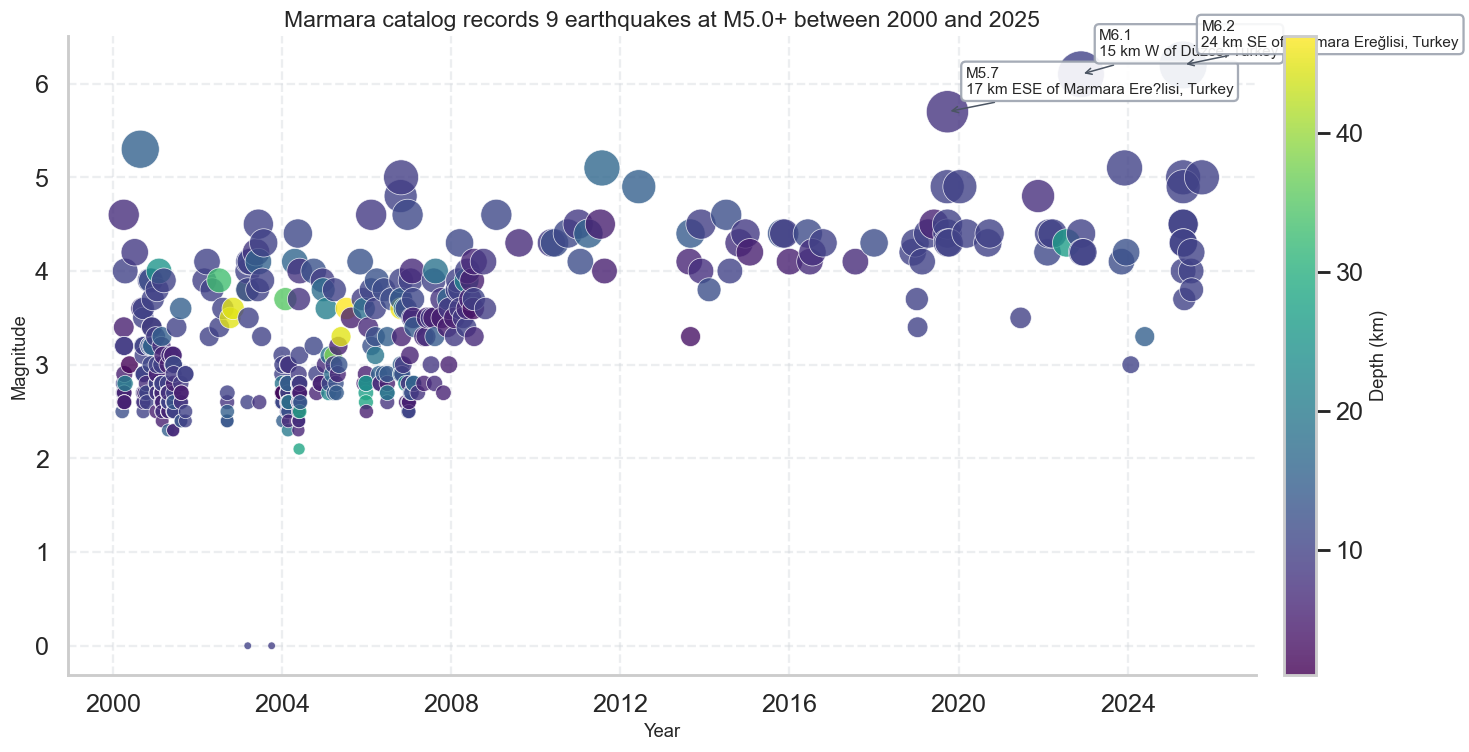

In [5]:
# Historical seismicity timeline: position shows time and magnitude,
# while size and color add secondary encodings for event importance and depth.
fig, ax = plt.subplots(figsize=(14, 7))

marker_sizes = 25 + (df_quakes["mag"] ** 3) * 4
scatter = ax.scatter(
    df_quakes["time"],
    df_quakes["mag"],
    s=marker_sizes,
    c=df_quakes["depth"],
    cmap="viridis",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
)

major_events = df_quakes.nlargest(3, "mag").sort_values("time")
for _, event in major_events.iterrows():
    ax.annotate(
        f"M{event['mag']:.1f}\n{event['place']}",
        xy=(event["time"], event["mag"]),
        xytext=(12, 12),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#9CA3AF", alpha=0.9),
        arrowprops=dict(arrowstyle="->", color="#4B5563", lw=1),
    )

m5_count = int((df_quakes["mag"] >= 5.0).sum())
ax.set_title(f"Marmara catalog records {m5_count} earthquakes at M5.0+ between {df_quakes['year'].min()} and {df_quakes['year'].max()}")
ax.set_xlabel("Year")
ax.set_ylabel("Magnitude")
ax.grid(True, linestyle="--", alpha=0.4)

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Depth (km)")

plt.tight_layout()
plt.show()

### Deliverable 3: Magnitude-Frequency Analysis

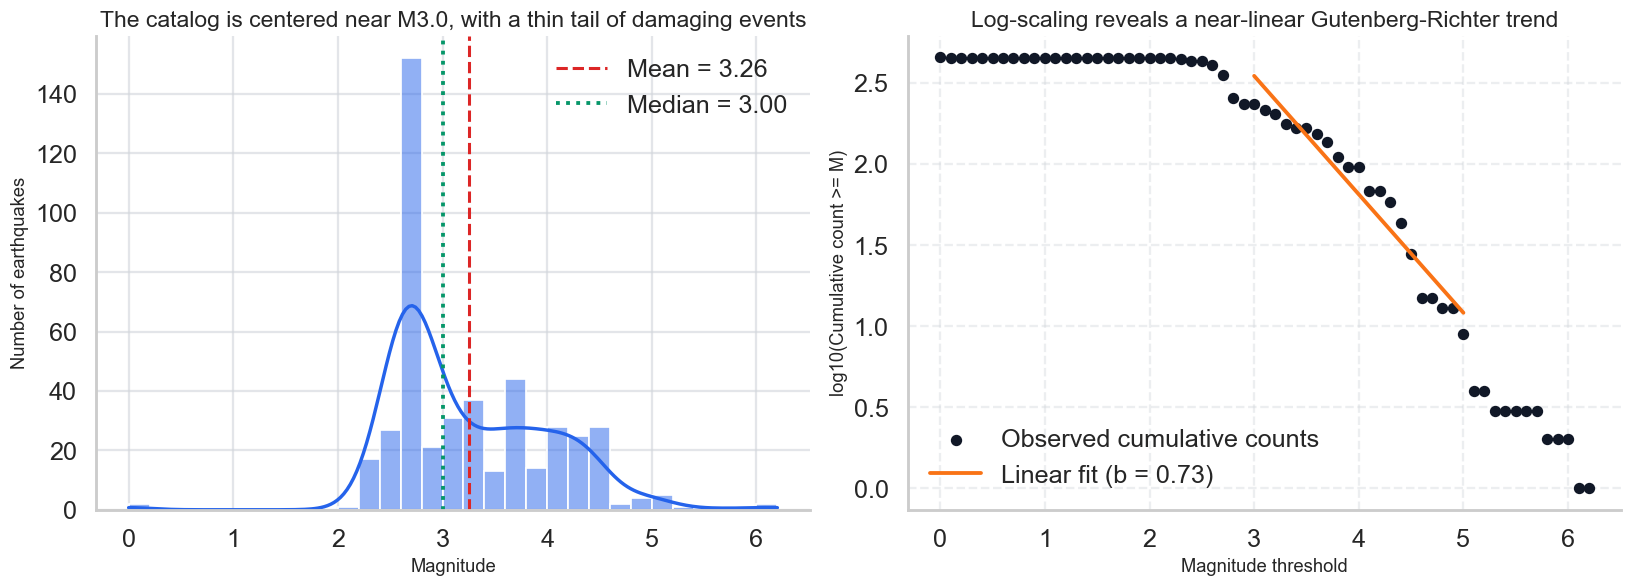

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Using 0.2-magnitude bins because the catalog reports magnitudes to roughly 0.1 precision,
# and 0.2 keeps the histogram readable without creating noisy micro-bins.
bins = np.arange(
    np.floor(df_quakes["mag"].min() * 5) / 5,
    np.ceil(df_quakes["mag"].max() * 5) / 5 + 0.2,
    0.2,
)

sns.histplot(df_quakes["mag"], bins=bins, kde=True, color="#2563EB", ax=axes[0])
mean_mag = df_quakes["mag"].mean()
median_mag = df_quakes["mag"].median()
axes[0].axvline(mean_mag, color="#DC2626", linestyle="--", lw=2, label=f"Mean = {mean_mag:.2f}")
axes[0].axvline(median_mag, color="#059669", linestyle=":", lw=2.5, label=f"Median = {median_mag:.2f}")
axes[0].set_title("The catalog is centered near M3.0, with a thin tail of damaging events")
axes[0].set_xlabel("Magnitude")
axes[0].set_ylabel("Number of earthquakes")
axes[0].legend(frameon=False)

mag_grid = np.arange(
    np.floor(df_quakes["mag"].min() * 10) / 10,
    np.ceil(df_quakes["mag"].max() * 10) / 10 + 0.1,
    0.1,
)
cumulative_counts = np.array([(df_quakes["mag"] >= mag).sum() for mag in mag_grid])
mask = cumulative_counts > 0
fit_mask = mask & (cumulative_counts >= 5) & (mag_grid >= 3.0)
if fit_mask.sum() < 2:
    fit_mask = mask

coeffs = np.polyfit(mag_grid[fit_mask], np.log10(cumulative_counts[fit_mask]), 1)
b_value = -coeffs[0]
fit_line = np.polyval(coeffs, mag_grid[fit_mask])

axes[1].scatter(mag_grid[mask], np.log10(cumulative_counts[mask]), color="#111827", s=35, label="Observed cumulative counts")
axes[1].plot(mag_grid[fit_mask], fit_line, color="#F97316", lw=2.5, label=f"Linear fit (b = {b_value:.2f})")
axes[1].set_title("Log-scaling reveals a near-linear Gutenberg-Richter trend")
axes[1].set_xlabel("Magnitude threshold")
axes[1].set_ylabel("log10(Cumulative count >= M)")
axes[1].legend(frameon=False)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Deliverable 4: Building Vulnerability or Population Risk

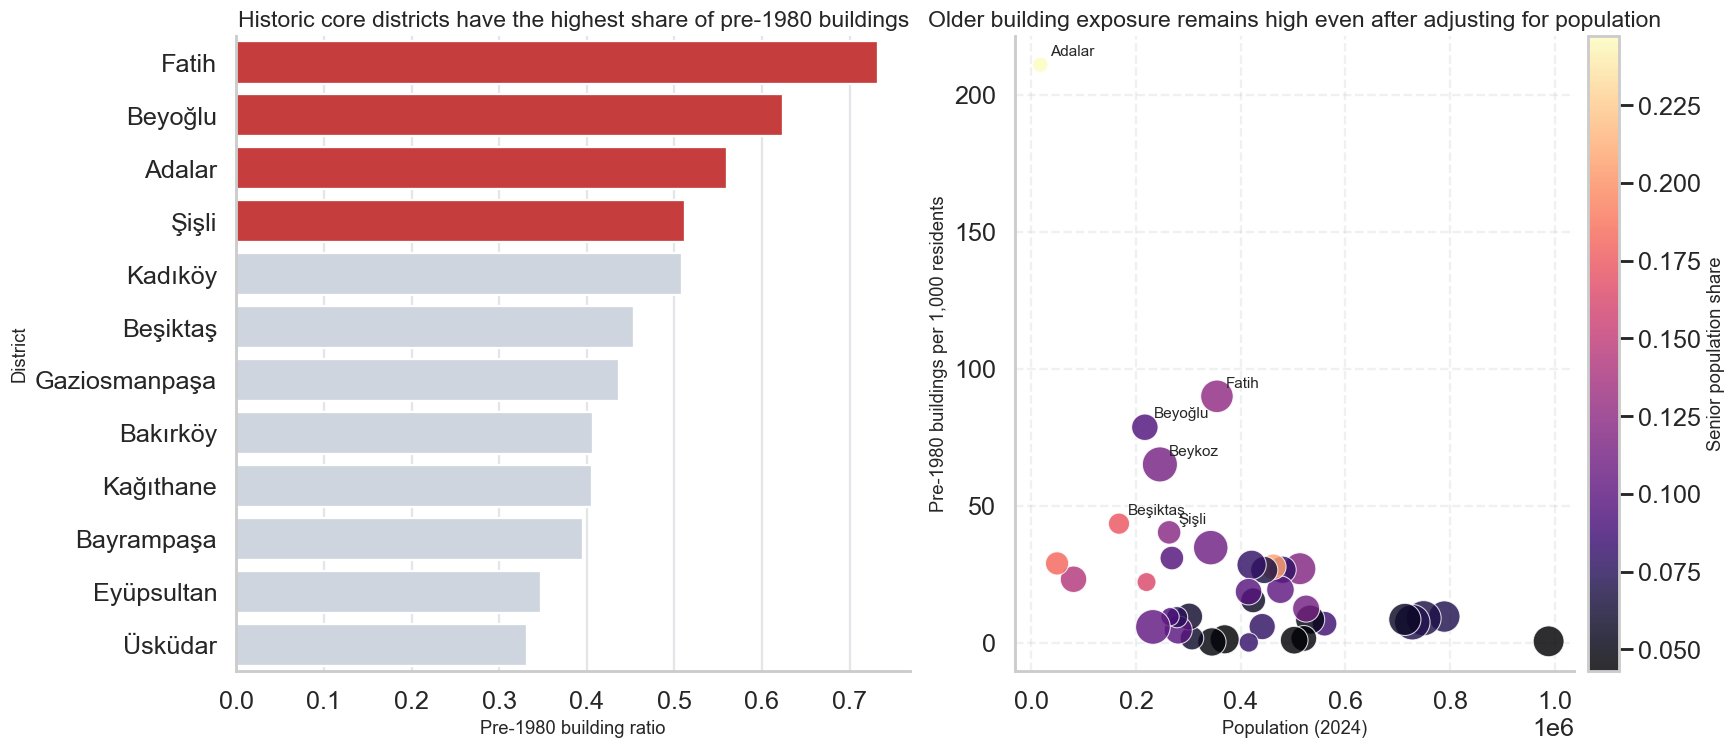

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ranked_old = df_districts.sort_values("old_building_ratio", ascending=False).head(12).copy()
palette = ["#DC2626" if value >= ranked_old["old_building_ratio"].nlargest(4).min() else "#CBD5E1" for value in ranked_old["old_building_ratio"]]
sns.barplot(
    data=ranked_old,
    x="old_building_ratio",
    y="district",
    hue="district",
    palette=palette,
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Historic core districts have the highest share of pre-1980 buildings")
axes[0].set_xlabel("Pre-1980 building ratio")
axes[0].set_ylabel("District")

scatter = axes[1].scatter(
    df_districts["population"],
    df_districts["old_buildings_per_1000"],
    s=40 + (df_districts["total_buildings"] / df_districts["total_buildings"].max()) * 500,
    c=df_districts["senior_share"],
    cmap="magma",
    alpha=0.82,
    edgecolor="white",
    linewidth=0.7,
)

for _, row in df_districts.nlargest(6, "old_buildings_per_1000").iterrows():
    axes[1].annotate(row["district"], (row["population"], row["old_buildings_per_1000"]), xytext=(6, 6), textcoords="offset points", fontsize=10)

axes[1].set_title("Older building exposure remains high even after adjusting for population")
axes[1].set_xlabel("Population (2024)")
axes[1].set_ylabel("Pre-1980 buildings per 1,000 residents")
axes[1].grid(True, linestyle="--", alpha=0.35)

cbar = fig.colorbar(scatter, ax=axes[1], pad=0.02)
cbar.set_label("Senior population share")

plt.tight_layout()
plt.show()

### Deliverable 5: Earthquake Hazard Visualization

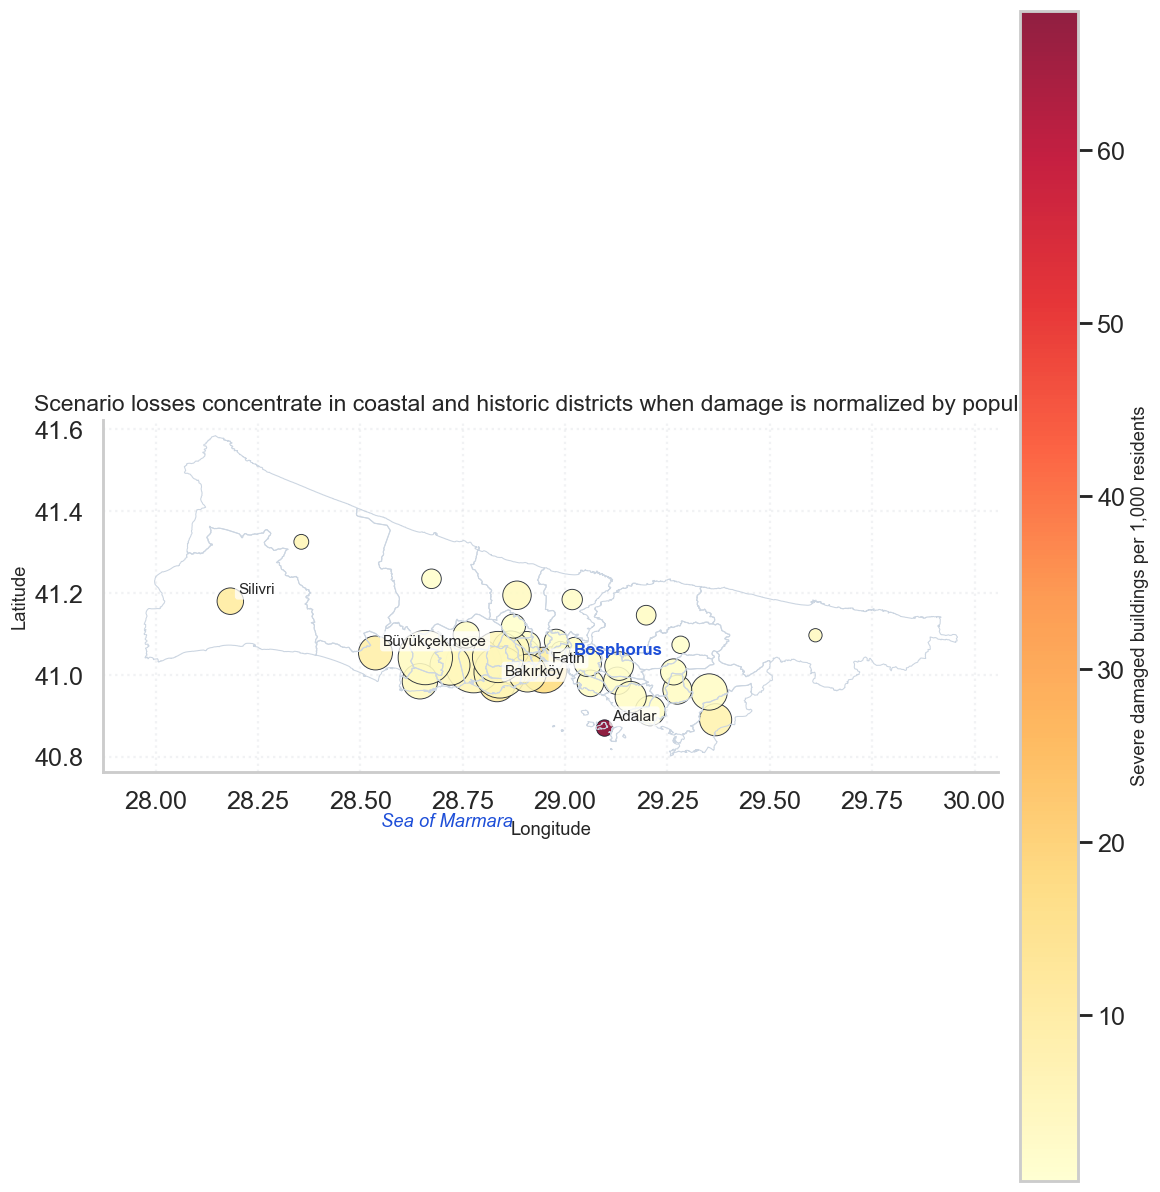

In [8]:
fig, ax = plt.subplots(figsize=(11, 11))

gdf_hazard.boundary.plot(ax=ax, color="#CBD5E1", linewidth=0.7)

bubble_sizes = 60 + (df_hazard["temporary_shelter"] / df_hazard["temporary_shelter"].max()) * 1300
scatter = ax.scatter(
    df_hazard["lon"],
    df_hazard["lat"],
    s=bubble_sizes,
    c=df_hazard["severe_damage_per_1000"],
    cmap="YlOrRd",
    alpha=0.88,
    edgecolor="#111827",
    linewidth=0.6,
)

for _, row in df_hazard.nlargest(5, "severe_damage_per_1000").iterrows():
    ax.annotate(
        row["district"],
        (row["lon"], row["lat"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
    )

ax.text(29.02, 41.05, "Bosphorus", color="#1D4ED8", fontsize=11, weight="bold")
ax.text(28.55, 40.63, "Sea of Marmara", color="#1D4ED8", fontsize=12, style="italic")
ax.set_title("Scenario losses concentrate in coastal and historic districts when damage is normalized by population")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.3)

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Severe damaged buildings per 1,000 residents")

plt.tight_layout()
plt.show()

### Deliverable 6: Multi-Panel Risk Dashboard + Reflection

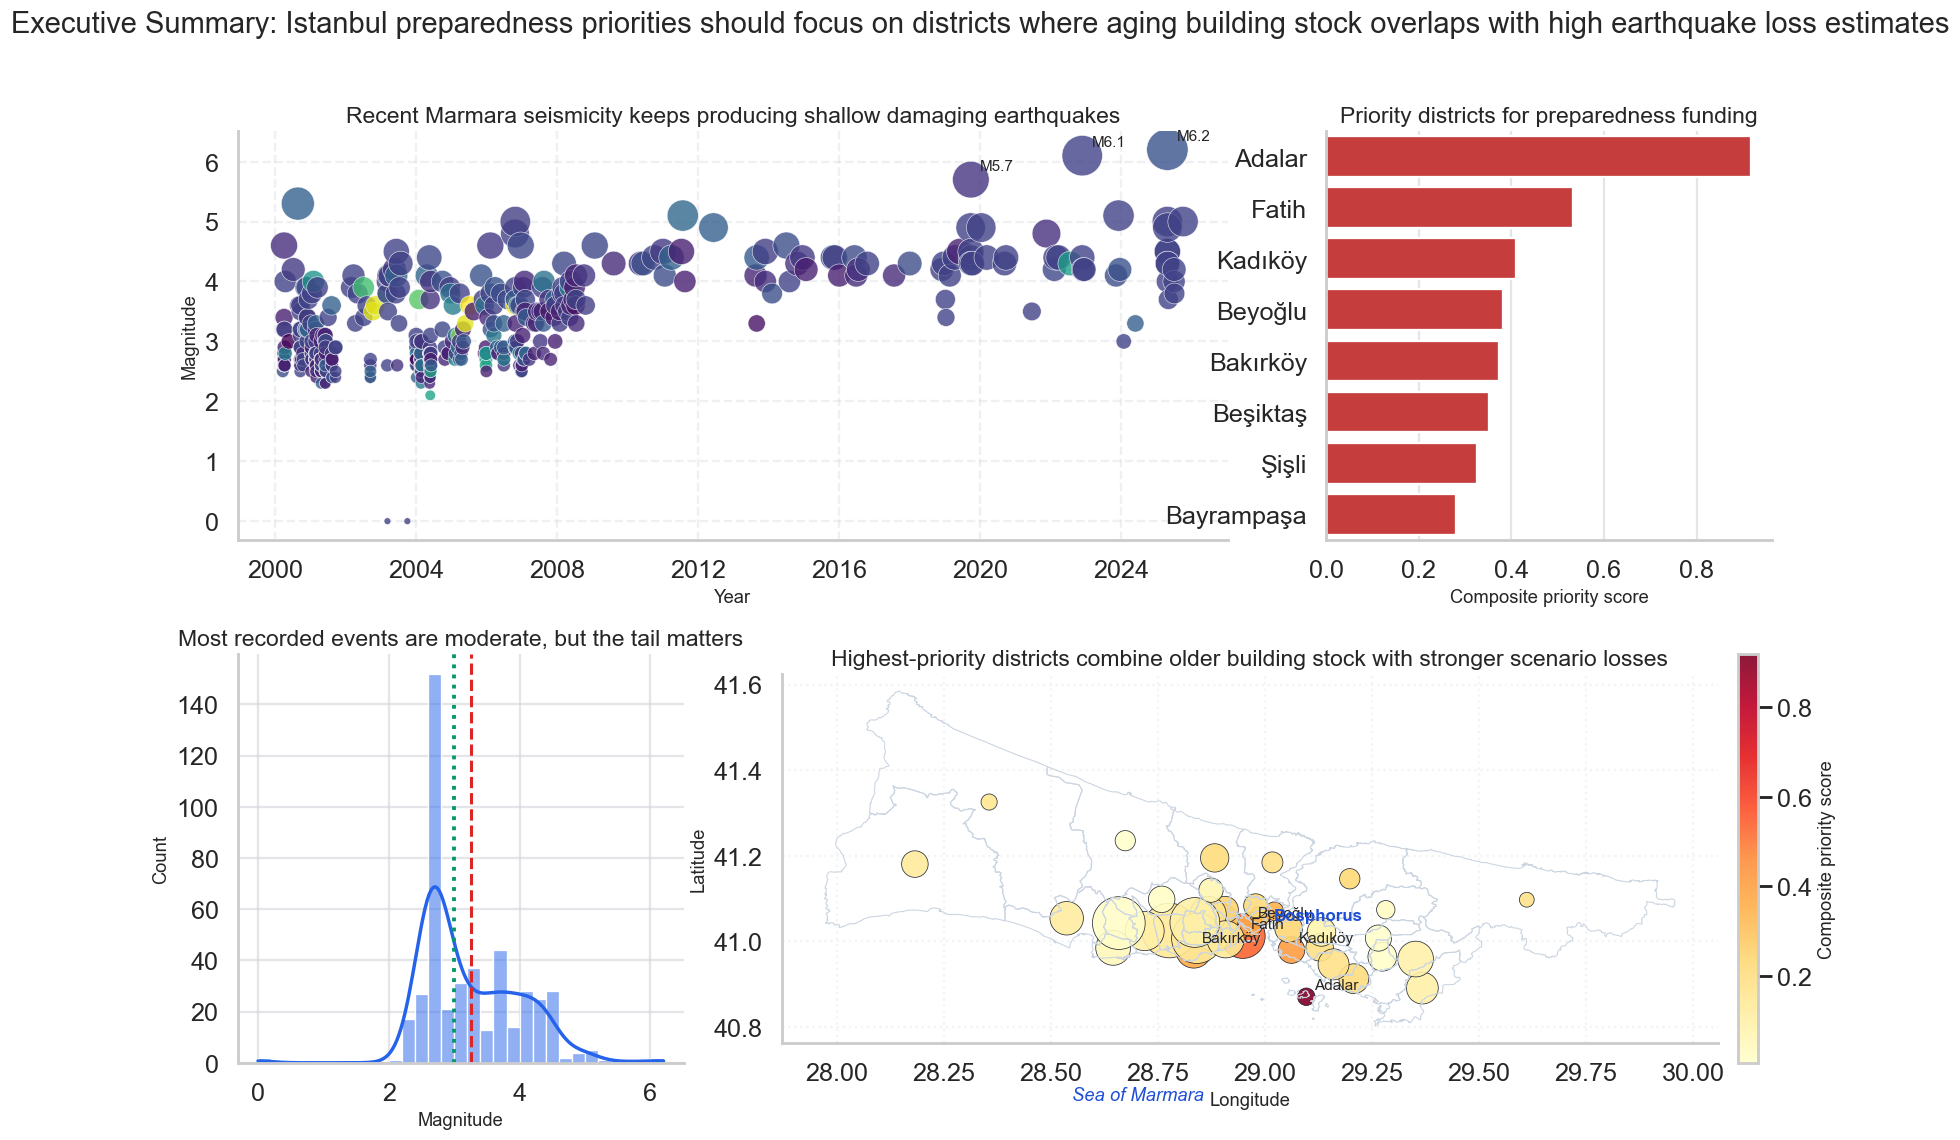

Dashboard saved to: /Users/bora/CE49X/Week04_Matplotlib_Visualization/lab/outputs/dashboard.png


In [9]:
dashboard_df = df_hazard.merge(
    df_districts[[
        "district_norm", "district", "population", "old_buildings",
        "old_building_ratio", "senior_share", "old_buildings_per_1000"
    ]],
    on="district_norm",
    how="left",
    suffixes=("", "_population"),
)

dashboard_top = dashboard_df.sort_values("priority_score", ascending=False).head(8).copy()
major_events = df_quakes.nlargest(3, "mag").sort_values("time")

m5_count = int((df_quakes["mag"] >= 5.0).sum())
top_priority = dashboard_top.iloc[0]
total_shelter_need = int(df_hazard["temporary_shelter"].sum())

fig = plt.figure(figsize=(18, 12), facecolor="#F8FAFC")
gs = fig.add_gridspec(3, 4, height_ratios=[0.9, 2.1, 2.6], hspace=0.34, wspace=0.32)

ax_kpi1 = fig.add_subplot(gs[0, 0])
ax_kpi2 = fig.add_subplot(gs[0, 1])
ax_kpi3 = fig.add_subplot(gs[0, 2])
ax_note = fig.add_subplot(gs[0, 3])
ax_timeline = fig.add_subplot(gs[1, :3])
ax_bar = fig.add_subplot(gs[1, 3])
ax_hist = fig.add_subplot(gs[2, 0])
ax_map = fig.add_subplot(gs[2, 1:])

for ax in [ax_kpi1, ax_kpi2, ax_kpi3, ax_note]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_visible(False)

for ax in [ax_timeline, ax_bar, ax_hist, ax_map]:
    ax.set_facecolor("white")

# KPI cards
ax_kpi1.text(0.05, 0.78, "Recorded events", fontsize=11, color="#64748B", transform=ax_kpi1.transAxes)
ax_kpi1.text(0.05, 0.38, f"{len(df_quakes)}", fontsize=28, weight="bold", color="#0F172A", transform=ax_kpi1.transAxes)
ax_kpi1.text(0.05, 0.12, f"{m5_count} earthquakes at M5.0+", fontsize=10, color="#334155", transform=ax_kpi1.transAxes)

ax_kpi2.text(0.05, 0.78, "Highest-priority district", fontsize=11, color="#64748B", transform=ax_kpi2.transAxes)
ax_kpi2.text(0.05, 0.38, top_priority["district"], fontsize=24, weight="bold", color="#991B1B", transform=ax_kpi2.transAxes)
ax_kpi2.text(0.05, 0.12, f"Score = {top_priority['priority_score']:.2f}", fontsize=10, color="#334155", transform=ax_kpi2.transAxes)

ax_kpi3.text(0.05, 0.78, "Scenario shelter need", fontsize=11, color="#64748B", transform=ax_kpi3.transAxes)
ax_kpi3.text(0.05, 0.38, f"{total_shelter_need:,}", fontsize=26, weight="bold", color="#0F172A", transform=ax_kpi3.transAxes)
ax_kpi3.text(0.05, 0.12, "Estimated temporary accommodation demand", fontsize=10, color="#334155", transform=ax_kpi3.transAxes)

ax_note.text(0.05, 0.78, "Derived metric used in D6", fontsize=11, color="#64748B", transform=ax_note.transAxes)
ax_note.text(
    0.05,
    0.42,
    "Priority score =\n0.45 x severe damage per 1,000\n+ 0.35 x old building ratio\n+ 0.20 x senior share",
    fontsize=10.5,
    color="#0F172A",
    transform=ax_note.transAxes,
    va="center",
)
ax_note.text(0.05, 0.08, "All three inputs are min-max normalized before combining.", fontsize=9, color="#475569", transform=ax_note.transAxes)

# Timeline panel
scatter = ax_timeline.scatter(
    df_quakes["time"],
    df_quakes["mag"],
    s=22 + (df_quakes["mag"] ** 3) * 3,
    c=df_quakes["depth"],
    cmap="viridis",
    alpha=0.82,
    edgecolor="white",
    linewidth=0.45,
)
for _, event in major_events.iterrows():
    ax_timeline.annotate(
        f"M{event['mag']:.1f}",
        (event["time"], event["mag"]),
        xytext=(6, 7),
        textcoords="offset points",
        fontsize=10,
        color="#111827",
    )
ax_timeline.set_title("Marmara seismicity shows a persistent tail of shallow, potentially damaging earthquakes", pad=10)
ax_timeline.set_xlabel("Year")
ax_timeline.set_ylabel("Magnitude")
ax_timeline.grid(True, linestyle="--", alpha=0.3)

cbar_timeline = fig.colorbar(scatter, ax=ax_timeline, fraction=0.022, pad=0.015)
cbar_timeline.set_label("Depth (km)")

# Ranking panel
bar_colors = ["#B91C1C" if i < 3 else "#FCA5A5" for i in range(len(dashboard_top))]
sns.barplot(data=dashboard_top, x="priority_score", y="district", palette=bar_colors, ax=ax_bar)
ax_bar.set_title("Preparedness funding ranking")
ax_bar.set_xlabel("Priority score")
ax_bar.set_ylabel("")
ax_bar.grid(True, axis="x", linestyle=":", alpha=0.35)

# Distribution panel
bins = np.arange(
    np.floor(df_quakes["mag"].min() * 5) / 5,
    np.ceil(df_quakes["mag"].max() * 5) / 5 + 0.2,
    0.2,
)
sns.histplot(df_quakes["mag"], bins=bins, kde=True, color="#2563EB", ax=ax_hist)
ax_hist.axvline(df_quakes["mag"].mean(), color="#DC2626", linestyle="--", lw=2, label=f"Mean = {df_quakes['mag'].mean():.2f}")
ax_hist.axvline(df_quakes["mag"].median(), color="#059669", linestyle=":", lw=2.5, label=f"Median = {df_quakes['mag'].median():.2f}")
ax_hist.set_title("Magnitude distribution")
ax_hist.set_xlabel("Magnitude")
ax_hist.set_ylabel("Count")
ax_hist.legend(frameon=False, fontsize=9)

# Map panel: choropleth + labeled top districts
map_plot = gdf_hazard.plot(
    column="priority_score",
    cmap="YlOrRd",
    linewidth=0.8,
    edgecolor="#CBD5E1",
    legend=True,
    ax=ax_map,
    legend_kwds={"label": "Composite priority score", "shrink": 0.75},
)
ax_map.scatter(
    dashboard_top["lon"],
    dashboard_top["lat"],
    s=90 + (dashboard_top["temporary_shelter"] / dashboard_top["temporary_shelter"].max()) * 700,
    color="#7C2D12",
    alpha=0.35,
    edgecolor="#7C2D12",
    linewidth=0.6,
)
for _, row in dashboard_top.head(5).iterrows():
    ax_map.annotate(
        row["district"],
        (row["lon"], row["lat"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )
ax_map.text(29.02, 41.05, "Bosphorus", color="#1D4ED8", fontsize=11, weight="bold")
ax_map.text(28.55, 40.63, "Sea of Marmara", color="#1D4ED8", fontsize=12, style="italic")
ax_map.set_title("Composite district vulnerability remains highest where aging stock and loss estimates overlap", pad=10)
ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")
ax_map.set_aspect("equal")
ax_map.grid(True, linestyle=":", alpha=0.22)

fig.suptitle(
    "Executive Dashboard: Istanbul preparedness spending should prioritize districts where older buildings, vulnerable populations, and scenario losses intersect",
    fontsize=20,
    weight="bold",
    y=0.98,
)
fig.text(
    0.015,
    0.012,
    "Sources: USGS Marmara earthquake catalog, IMM population data, IMM neighborhood building counts, IMM Mw 7.5 earthquake scenario results, and Istanbul district boundaries.",
    fontsize=9.5,
    color="#475569",
)

fig.savefig(OUTPUT_DIR / "dashboard.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"Dashboard saved to: {OUTPUT_DIR / 'dashboard.png'}")

#### Reflection

**1. Chart type justification (D2-D5):**

- **D2 - Seismicity timeline scatter:** I used a scatter plot because the theory notebook emphasizes that **position is the most accurate visual channel** for quantitative data. Time on the x-axis and magnitude on the y-axis make the trend easy to interpret, while marker size adds emphasis and color encodes depth as a secondary variable without overwhelming the main message.
- **D3 - Histogram + Gutenberg-Richter plot:** The histogram is appropriate for showing the **distribution** of magnitudes, and the KDE helps reveal the overall shape without adding chartjunk. The Gutenberg-Richter panel applies **data transformation** through the log scale, which is exactly the kind of transformation discussed in the theory notebook for making hidden structure visible.
- **D4 - Sorted bar chart + scatter plot:** I used a sorted bar chart because the task is a **categorical comparison across districts**, and sorting by pre-1980 building ratio supports quick ranking. The second scatter plot is better for showing the relationship between population exposure and older-building burden, which matches the chart selection framework for comparing two quantitative variables.
- **D5 - Spatial bubble map:** Because the data are geographic, the most honest visual form is a **spatial chart** rather than a non-spatial bar chart. I used a sequential colormap (`YlOrRd`) to avoid the false boundaries produced by rainbow palettes and added annotations so the audience can immediately focus on the highest-risk districts.

**2. Audience adaptation (seismologists vs. municipal council):**

- For **seismologists**, I would show more technical hazard metrics such as PGA or spectral acceleration and include the exact scenario assumptions, uncertainty ranges, and model limitations directly on the plots. The current notebook intentionally simplifies those details because the municipal council needs an executive summary, not a model-validation figure.
- I would also replace some of the simplified labels with more analytical content, such as the full Gutenberg-Richter fit range, residuals, and district-level uncertainty bands. For elected officials, the current version prioritizes clarity, prioritization, and actionability over technical completeness.

**3. Self-critique (weakest visualization + improvement plan):**

The weakest visualization is the **D5 bubble map**. It communicates spatial variation clearly, but using one centroid per district still hides within-district variation and can make large districts look more uniform than they really are. To improve it, I would replace the centroid bubbles with a full choropleth or neighborhood-level map and add a stronger legend note about uncertainty, which would address the theory notebook's warning against **over-simplification of spatial data**.

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr